# 问题二：目标差分 + 截断到 ±1 + 原始自变量 + 随机 80/20 + 五模型拟合

本 notebook 按你要求重新构建 P2 数据处理与建模流程：

```text
1. 读取数据
2. 缺失值处理
3. 仅对 FILT. NTU 差分：当前值 - 前一个时间节点值
4. 仅对 FILT. NTU 差分截断：正数最多为 1，负数最小为 -1
5. 随机划分 80% train / 20% test
6. 使用 XGBoost、GAM、Random Forest、LightGBM、小型神经网络五个模型学习
7. 拟合并输出结果
8. 呈现多种可视化图表
```

---

## 建模目标

第二题目标变量仍为：

```text
FILT. NTU
```

但本 notebook 建模的是其**截断后一阶差分**：

```text
ΔFILT.NTU_t = FILT.NTU_t - FILT.NTU_{t-1}
```

然后截断为：

```text
ΔFILT.NTU_clip1_t =
    1,  if ΔFILT.NTU_t > 1
    ΔFILT.NTU_t, if -1 <= ΔFILT.NTU_t <= 1
    -1, if ΔFILT.NTU_t < -1
```

也就是：

```python
np.clip(delta, -1, 1)
```

---

## 输入特征

第二问核心自变量保持原始水平值，不进行差分或截断：

```text
R/W NTU
R/W PH
ALUM
F/RIDE
R/W FLOW
```

并构造其原始水平值的 lag 特征：

```text
X_lag0 至 X_lag6
```

另外加入目标自身差分历史项：

```text
ΔFILT.NTU_clip1_lag1
ΔFILT.NTU_clip1_lag2
ΔFILT.NTU_clip1_lag3
```

---

## 输出目录

```text
outputs/problem2_diff_clip1_random80/
```

重点输出：

```text
problem2_diff_clip1_model_results.xlsx
problem2_diff_clip1_test_predictions.xlsx
problem2_diff_clip1_feature_importance.xlsx
problem2_diff_clip1_summary.xlsx
figures/
models/
```


## 1. 导入依赖库

LightGBM 如果本地环境没有安装，会自动跳过并提示安装。  
XGBoost 同理。


In [1]:
from pathlib import Path
import warnings
import joblib
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    XGB_IMPORT_ERROR = e

try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except Exception as e:
    LGBM_AVAILABLE = False
    LGBM_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 260)

print("XGBoost available:", XGB_AVAILABLE)
if not XGB_AVAILABLE:
    print("XGBoost import error:", XGB_IMPORT_ERROR)

print("LightGBM available:", LGBM_AVAILABLE)
if not LGBM_AVAILABLE:
    print("LightGBM import error:", LGBM_IMPORT_ERROR)
    print("如需启用 LightGBM，可在当前环境运行：pip install lightgbm")


XGBoost available: True
LightGBM available: False
LightGBM import error: No module named 'lightgbm'
如需启用 LightGBM，可在当前环境运行：pip install lightgbm


## 2. 参数设置

这里保持流程清晰，不做复杂超参数搜索。


In [2]:
TARGET_COL = "FILT. NTU"
OUTPUT_DIR_NAME = "problem2_diff_clip1_random80"

RANDOM_STATE = 42
TEST_SIZE = 0.20
RECORD_INTERVAL_HOURS = 2

# 差分截断范围
DIFF_CLIP_LOWER = -1.0
DIFF_CLIP_UPPER = 1.0

# 第二问核心变量
CORE_FEATURES = [
    "R/W NTU",
    "R/W PH",
    "ALUM",
    "F/RIDE",
    "R/W FLOW",
]

# 原始外生变量滞后阶数
EXOG_LEVEL_LAGS = list(range(0, 7))  # lag0-lag6，对应当前至过去 12 小时

# 目标自身差分历史项
TARGET_DIFF_HISTORY_LAGS = [1, 2, 3]  # 过去 2/4/6 小时的 ΔFILT.NTU_clip1

# 是否把模型预测也限制在 [-1, 1]
CLIP_PREDICTIONS = True

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

从原始 `merged.xlsx` 读取，不依赖任何中间文件。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []

    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        try:
            for p in parent.rglob(filename):
                return p.resolve()
        except Exception:
            pass

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： /Users/jinyu/workspace/2026亚太杯/codes/p2
使用数据文件： /Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
输出目录： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80


## 4. 读取数据并构造时间列

构造：

```text
DATETIME
OP_DATE
```

`OP_DATE` 使用运行日定义：

```text
07:00 至次日 05:00 归为同一个运行日
```


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。请检查 merged.xlsx。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(12))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 5. 缺失值处理

处理原则：

```text
1. 只保留第二问目标变量和核心输入变量；
2. 所有变量转为 numeric；
3. F/RIDE 缺失值填 0，R/W PH 缺失值填 7，ALUM 缺失值填 0.06；
4. 除上述三个变量外，其余变量按时间顺序进行线性插值；
5. 插值后仍缺失的值再 forward fill / backward fill；
6. 后续模型 pipeline 内仍保留 SimpleImputer(strategy='median')，防止 lag 特征产生的少量缺失影响训练。
```

输出：

```text
problem2_diff_clip1_missing_audit.xlsx
```


In [5]:
available_features = [c for c in CORE_FEATURES if c in df.columns]
missing_features = [c for c in CORE_FEATURES if c not in df.columns]

print("可用核心输入变量：", available_features)
print("缺失核心输入变量：", missing_features)

use_cols = ["DATETIME", "OP_DATE", TARGET_COL] + available_features
use_cols = list(dict.fromkeys(use_cols))

data = df[use_cols].copy().sort_values("DATETIME").reset_index(drop=True)

# 转 numeric
for col in [TARGET_COL] + available_features:
    data[col] = pd.to_numeric(data[col], errors="coerce")

missing_before = pd.DataFrame({
    "column": [TARGET_COL] + available_features,
    "missing_count_before": [int(data[c].isna().sum()) for c in [TARGET_COL] + available_features],
    "missing_rate_before": [float(data[c].isna().mean()) for c in [TARGET_COL] + available_features],
})

# 指定变量使用固定值填充
fixed_fill_values = {
    "F/RIDE": 0,
    "R/W PH": 7,
    "ALUM": 0.06,
}
for col, fill_value in fixed_fill_values.items():
    if col in data.columns:
        data[col] = data[col].fillna(fill_value)

# 其他变量线性插值 + 前后填充
for col in [TARGET_COL] + available_features:
    if col in fixed_fill_values:
        continue

    data[col] = (
        data[col]
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

missing_after = pd.DataFrame({
    "column": [TARGET_COL] + available_features,
    "missing_count_after": [int(data[c].isna().sum()) for c in [TARGET_COL] + available_features],
    "missing_rate_after": [float(data[c].isna().mean()) for c in [TARGET_COL] + available_features],
})

missing_audit = missing_before.merge(missing_after, on="column", how="left")

missing_audit_path = OUTPUT_DIR / "problem2_diff_clip1_missing_audit.xlsx"
missing_audit.to_excel(missing_audit_path, index=False)

print("缺失值处理审计表已保存：", missing_audit_path)
display(missing_audit)

print("处理后数据规模：", data.shape)
display(data.head())


可用核心输入变量： ['R/W NTU', 'R/W PH', 'ALUM', 'F/RIDE', 'R/W FLOW']
缺失核心输入变量： []
缺失值处理审计表已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_missing_audit.xlsx


,column,missing_count_before,missing_rate_before,missing_count_after,missing_rate_after
0,FILT. NTU,0,0.000000,0,0.0
1,R/W NTU,0,0.000000,0,0.0
2,R/W PH,1644,0.301099,0,0.0
3,ALUM,1644,0.301099,0,0.0
4,F/RIDE,0,0.000000,0,0.0
5,R/W FLOW,0,0.000000,0,0.0


处理后数据规模： (5460, 8)


,DATETIME,OP_DATE,FILT. NTU,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,0.04,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.05,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.05,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.05,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.05,56,7.0,0.04,0.0,44.5


## 6. 差分处理：当前值 - 前一个时间节点值

对目标变量和核心输入变量都做一阶差分：

```text
DIFF_X_t = X_t - X_{t-1}
```

输出：

```text
problem2_diff_raw_data.xlsx
```


In [6]:
def safe_name(col):
    return (
        str(col)
        .replace("/", "_")
        .replace(" ", "_")
        .replace(".", "")
        .replace("+", "plus")
        .replace("-", "_")
    )


diff_data = data.copy()

target_diff_col = f"DIFF_{safe_name(TARGET_COL)}"
diff_data[target_diff_col] = diff_data[TARGET_COL] - diff_data[TARGET_COL].shift(1)

diff_raw_path = OUTPUT_DIR / "problem2_diff_raw_data.xlsx"
diff_data[["DATETIME", "OP_DATE"] + [TARGET_COL] + available_features + [target_diff_col]].to_excel(diff_raw_path, index=False)

print("原始差分数据已保存：", diff_raw_path)
print("目标差分列：", target_diff_col)
display(diff_data[["DATETIME", "OP_DATE", TARGET_COL, target_diff_col] + available_features].head(12))


原始差分数据已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_raw_data.xlsx
目标差分列： DIFF_FILT_NTU


,DATETIME,OP_DATE,FILT. NTU,DIFF_FILT_NTU,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,0.04,NaN,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.05,0.01,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.05,0.00,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.05,0.00,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.05,0.00,56,7.0,0.04,0.0,44.5
5,2025-01-01 17:00:00,2025-01-01,0.06,0.01,75,7.0,0.04,0.0,44.5
6,2025-01-01 19:00:00,2025-01-01,0.05,-0.01,102,7.0,0.04,0.0,44.2
7,2025-01-01 21:00:00,2025-01-01,0.05,0.00,99,7.0,0.04,0.0,44.2
8,2025-01-01 23:00:00,2025-01-01,0.05,0.00,100,7.0,0.04,0.0,48.9
9,2025-01-02 01:00:00,2025-01-01,0.05,0.00,67,7.0,0.04,0.0,48.6


## 7. 对差分值截断到 ±1

规则：

```text
如果差分值 > 1，则变成 1
如果差分值 < -1，则变成 -1
否则保持原值
```

也就是：

```python
np.clip(diff_value, -1, 1)
```

输出：

```text
problem2_diff_clip1_audit.xlsx
problem2_diff_clip1_data.xlsx
```


In [7]:
clip_data = diff_data.copy()

target_clip_col = f"{target_diff_col}_CLIP1"
clip_data[target_clip_col] = clip_data[target_diff_col].clip(
    lower=DIFF_CLIP_LOWER,
    upper=DIFF_CLIP_UPPER,
)

valid_raw = clip_data[target_diff_col].dropna()
valid_clip = clip_data[target_clip_col].dropna()

clip_audit_records = [{
    "original_variable": TARGET_COL,
    "diff_column": target_diff_col,
    "clip_column": target_clip_col,
    "raw_diff_min": valid_raw.min() if len(valid_raw) else np.nan,
    "raw_diff_max": valid_raw.max() if len(valid_raw) else np.nan,
    "clip_min": valid_clip.min() if len(valid_clip) else np.nan,
    "clip_max": valid_clip.max() if len(valid_clip) else np.nan,
    "count_above_1_before_clip": int((clip_data[target_diff_col] > DIFF_CLIP_UPPER).sum()),
    "count_below_minus1_before_clip": int((clip_data[target_diff_col] < DIFF_CLIP_LOWER).sum()),
    "count_equal_1_after_clip": int((clip_data[target_clip_col] == DIFF_CLIP_UPPER).sum()),
    "count_equal_minus1_after_clip": int((clip_data[target_clip_col] == DIFF_CLIP_LOWER).sum()),
}]

clip_audit_df = pd.DataFrame(clip_audit_records)

clip_audit_path = OUTPUT_DIR / "problem2_diff_clip1_audit.xlsx"
clip_data_path = OUTPUT_DIR / "problem2_diff_clip1_data.xlsx"

clip_audit_df.to_excel(clip_audit_path, index=False)
clip_data[["DATETIME", "OP_DATE", TARGET_COL, target_diff_col, target_clip_col] + available_features].to_excel(clip_data_path, index=False)

print("差分截断审计表已保存：", clip_audit_path)
print("差分截断数据已保存：", clip_data_path)

display(clip_audit_df)
display(clip_data[["DATETIME", "OP_DATE", target_diff_col, target_clip_col] + available_features].head(30))


差分截断审计表已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_audit.xlsx
差分截断数据已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_data.xlsx


,original_variable,diff_column,clip_column,raw_diff_min,raw_diff_max,clip_min,clip_max,count_above_1_before_clip,count_below_minus1_before_clip,count_equal_1_after_clip,count_equal_minus1_after_clip
0,FILT. NTU,DIFF_FILT_NTU,DIFF_FILT_NTU_CLIP1,-3.89,7.6,-1.0,1.0,27,31,28,31


,DATETIME,OP_DATE,DIFF_FILT_NTU,DIFF_FILT_NTU_CLIP1,R/W NTU,R/W PH,ALUM,F/RIDE,R/W FLOW
0,2025-01-01 07:00:00,2025-01-01,NaN,NaN,150,7.0,0.04,0.0,45.3
1,2025-01-01 09:00:00,2025-01-01,0.01,0.01,120,7.0,0.04,0.0,45.2
2,2025-01-01 11:00:00,2025-01-01,0.00,0.00,82,7.0,0.04,0.0,44.9
3,2025-01-01 13:00:00,2025-01-01,0.00,0.00,62,7.0,0.04,0.0,44.9
4,2025-01-01 15:00:00,2025-01-01,0.00,0.00,56,7.0,0.04,0.0,44.5
5,2025-01-01 17:00:00,2025-01-01,0.01,0.01,75,7.0,0.04,0.0,44.5
6,2025-01-01 19:00:00,2025-01-01,-0.01,-0.01,102,7.0,0.04,0.0,44.2
7,2025-01-01 21:00:00,2025-01-01,0.00,0.00,99,7.0,0.04,0.0,44.2
8,2025-01-01 23:00:00,2025-01-01,0.00,0.00,100,7.0,0.04,0.0,48.9
9,2025-01-02 01:00:00,2025-01-01,0.00,0.00,67,7.0,0.04,0.0,48.6


## 8. 构造建模特征

目标：

```text
target_DIFF_FILT_NTU_CLIP1
```

即：

```text
ΔFILT.NTU_clip1
```

输入特征包括：

```text
1. 外生变量原始水平值的 lag0-lag6
2. 目标自身差分截断后的历史 lag1-lag3
```

这样模型学习的是：

```text
外生变量原始水平及其历史 + 目标自身变化惯性 → 当前 FILT. NTU 变化量
```


In [8]:
model_df = clip_data.copy()

target_name = "target_DIFF_FILT_NTU_CLIP1"
model_df[target_name] = model_df[target_clip_col]

feature_records = []
feature_cols = []

# 外生变量保持原始水平值，构造 lag0-lag6
for var in available_features:
    base_col = safe_name(var)

    for lag in EXOG_LEVEL_LAGS:
        feature_col = f"{base_col}_lag{lag}"
        model_df[feature_col] = model_df[var].shift(lag)
        feature_cols.append(feature_col)

        feature_records.append({
            "feature": feature_col,
            "source_variable": var,
            "base_column": var,
            "feature_type": "exogenous_level_lag",
            "lag": lag,
            "lag_hours": lag * RECORD_INTERVAL_HOURS,
        })

# 目标自身差分历史 lag1-lag3
for lag in TARGET_DIFF_HISTORY_LAGS:
    feature_col = f"{target_clip_col}_lag{lag}"
    model_df[feature_col] = model_df[target_clip_col].shift(lag)
    feature_cols.append(feature_col)

    feature_records.append({
        "feature": feature_col,
        "source_variable": TARGET_COL,
        "base_column": target_clip_col,
        "feature_type": "target_diff_clip_history_lag",
        "lag": lag,
        "lag_hours": lag * RECORD_INTERVAL_HOURS,
    })

feature_cols = list(dict.fromkeys(feature_cols))

model_data = model_df[["DATETIME", "OP_DATE", target_name] + feature_cols].copy()

# 删除目标缺失行；feature 缺失交给 pipeline 内 imputer
model_data = model_data.dropna(subset=["DATETIME", target_name]).reset_index(drop=True)

feature_summary_df = pd.DataFrame(feature_records)

model_data_path = OUTPUT_DIR / "problem2_diff_clip1_model_data.xlsx"
feature_summary_path = OUTPUT_DIR / "problem2_diff_clip1_feature_summary.xlsx"

model_data.to_excel(model_data_path, index=False)
feature_summary_df.to_excel(feature_summary_path, index=False)

print("建模数据已保存：", model_data_path)
print("特征说明已保存：", feature_summary_path)
print("建模数据规模：", model_data.shape)
print("特征数量：", len(feature_cols))

display(feature_summary_df.head(30))
display(model_data.head())


建模数据已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_model_data.xlsx
特征说明已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_feature_summary.xlsx
建模数据规模： (5459, 41)
特征数量： 38


,feature,source_variable,base_column,feature_type,lag,lag_hours
0,R_W_NTU_lag0,R/W NTU,R/W NTU,exogenous_level_lag,0,0
1,R_W_NTU_lag1,R/W NTU,R/W NTU,exogenous_level_lag,1,2
2,R_W_NTU_lag2,R/W NTU,R/W NTU,exogenous_level_lag,2,4
3,R_W_NTU_lag3,R/W NTU,R/W NTU,exogenous_level_lag,3,6
4,R_W_NTU_lag4,R/W NTU,R/W NTU,exogenous_level_lag,4,8
5,R_W_NTU_lag5,R/W NTU,R/W NTU,exogenous_level_lag,5,10
6,R_W_NTU_lag6,R/W NTU,R/W NTU,exogenous_level_lag,6,12
7,R_W_PH_lag0,R/W PH,R/W PH,exogenous_level_lag,0,0
8,R_W_PH_lag1,R/W PH,R/W PH,exogenous_level_lag,1,2
9,R_W_PH_lag2,R/W PH,R/W PH,exogenous_level_lag,2,4


,DATETIME,OP_DATE,target_DIFF_FILT_NTU_CLIP1,R_W_NTU_lag0,R_W_NTU_lag1,R_W_NTU_lag2,R_W_NTU_lag3,R_W_NTU_lag4,R_W_NTU_lag5,R_W_NTU_lag6,R_W_PH_lag0,R_W_PH_lag1,R_W_PH_lag2,R_W_PH_lag3,R_W_PH_lag4,R_W_PH_lag5,R_W_PH_lag6,ALUM_lag0,ALUM_lag1,ALUM_lag2,ALUM_lag3,ALUM_lag4,ALUM_lag5,ALUM_lag6,F_RIDE_lag0,F_RIDE_lag1,F_RIDE_lag2,F_RIDE_lag3,F_RIDE_lag4,F_RIDE_lag5,F_RIDE_lag6,R_W_FLOW_lag0,R_W_FLOW_lag1,R_W_FLOW_lag2,R_W_FLOW_lag3,R_W_FLOW_lag4,R_W_FLOW_lag5,R_W_FLOW_lag6,DIFF_FILT_NTU_CLIP1_lag1,DIFF_FILT_NTU_CLIP1_lag2,DIFF_FILT_NTU_CLIP1_lag3
0,2025-01-01 09:00:00,2025-01-01,0.01,120,150.0,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,NaN,NaN,NaN,NaN,0.04,0.04,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,45.2,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 11:00:00,2025-01-01,0.00,82,120.0,150.0,NaN,NaN,NaN,NaN,7.0,7.0,7.0,NaN,NaN,NaN,NaN,0.04,0.04,0.04,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,44.9,45.2,45.3,NaN,NaN,NaN,NaN,0.01,NaN,NaN
2,2025-01-01 13:00:00,2025-01-01,0.00,62,82.0,120.0,150.0,NaN,NaN,NaN,7.0,7.0,7.0,7.0,NaN,NaN,NaN,0.04,0.04,0.04,0.04,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,44.9,44.9,45.2,45.3,NaN,NaN,NaN,0.00,0.01,NaN
3,2025-01-01 15:00:00,2025-01-01,0.00,56,62.0,82.0,120.0,150.0,NaN,NaN,7.0,7.0,7.0,7.0,7.0,NaN,NaN,0.04,0.04,0.04,0.04,0.04,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,44.5,44.9,44.9,45.2,45.3,NaN,NaN,0.00,0.00,0.01
4,2025-01-01 17:00:00,2025-01-01,0.01,75,56.0,62.0,82.0,120.0,150.0,NaN,7.0,7.0,7.0,7.0,7.0,7.0,NaN,0.04,0.04,0.04,0.04,0.04,0.04,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,44.5,44.5,44.9,44.9,45.2,45.3,NaN,0.00,0.00,0.00


## 9. 随机划分数据：80% train / 20% test

使用：

```python
train_test_split(..., test_size=0.20, random_state=42, shuffle=True)
```

这是完全随机划分，不按时间顺序。


In [9]:
train_df, test_df = train_test_split(
    model_data,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

# 仅为了画图时更清楚，划分之后按时间排序；划分本身已经是随机的。
train_df = train_df.sort_values("DATETIME").reset_index(drop=True)
test_df = test_df.sort_values("DATETIME").reset_index(drop=True)

X_train = train_df[feature_cols].copy()
y_train = train_df[target_name].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_name].copy()

print("总样本数：", len(model_data))
print("训练集：", X_train.shape, "随机抽样；时间范围：", train_df["DATETIME"].min(), "至", train_df["DATETIME"].max())
print("测试集：", X_test.shape, "随机抽样；时间范围：", test_df["DATETIME"].min(), "至", test_df["DATETIME"].max())


总样本数： 5459
训练集： (4367, 38) 随机抽样；时间范围： 2025-01-01 09:00:00 至 2026-04-01 05:00:00
测试集： (1092, 38) 随机抽样；时间范围： 2025-01-02 01:00:00 至 2026-03-31 19:00:00


## 10. 定义五个模型

五个模型：

```text
1. XGBoost
2. GAM
3. Random Forest
4. LightGBM
5. Small Neural Network
```

GAM 采用：

```text
SplineTransformer + Ridge
```

小型神经网络采用：

```text
MLPRegressor(hidden_layer_sizes=(32, 16))
```


In [10]:
def build_models():
    models = {}

    if XGB_AVAILABLE:
        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])
    else:
        print("XGBoost 不可用，跳过。")

    models["GAM"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("spline", SplineTransformer(
            n_knots=5,
            degree=3,
            include_bias=False,
        )),
        ("model", Ridge(alpha=10.0)),
    ])

    models["Random Forest"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            max_features="sqrt",
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ])

    if LGBM_AVAILABLE:
        models["LightGBM"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMRegressor(
                n_estimators=500,
                learning_rate=0.03,
                max_depth=-1,
                num_leaves=31,
                subsample=0.85,
                colsample_bytree=0.85,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            )),
        ])
    else:
        print("LightGBM 不可用，使用 HistGradientBoostingRegressor 作为备用近似模型。")
        models["LightGBM_fallback_HistGBR"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingRegressor(
                max_iter=500,
                learning_rate=0.03,
                max_leaf_nodes=31,
                random_state=RANDOM_STATE,
            )),
        ])

    models["Small Neural Network"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=0.001,
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=RANDOM_STATE,
        )),
    ])

    return models


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    sign_true = np.sign(y_true)
    sign_pred = np.sign(y_pred)
    direction_accuracy = np.mean(sign_true == sign_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Direction_Accuracy": direction_accuracy,
    }


models = build_models()
print("实际训练模型：", list(models.keys()))


LightGBM 不可用，使用 HistGradientBoostingRegressor 作为备用近似模型。
实际训练模型： ['XGBoost', 'GAM', 'Random Forest', 'LightGBM_fallback_HistGBR', 'Small Neural Network']


## 11. 训练模型并输出拟合结果

输出：

```text
problem2_diff_clip1_model_results.xlsx
problem2_diff_clip1_test_predictions.xlsx
models/*.joblib
```


In [11]:
results_records = []
prediction_frames = []
trained_models = {}

for model_name, model in models.items():
    print("=" * 80)
    print("Training:", model_name)
    print("=" * 80)

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    if CLIP_PREDICTIONS:
        y_pred_train = np.clip(y_pred_train, DIFF_CLIP_LOWER, DIFF_CLIP_UPPER)
        y_pred_test = np.clip(y_pred_test, DIFF_CLIP_LOWER, DIFF_CLIP_UPPER)

    train_metrics = evaluate_regression(y_train, y_pred_train)
    test_metrics = evaluate_regression(y_test, y_pred_test)

    record = {
        "model": model_name,
        "n_features": len(feature_cols),
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "train_MAE": train_metrics["MAE"],
        "train_RMSE": train_metrics["RMSE"],
        "train_R2": train_metrics["R2"],
        "train_Direction_Accuracy": train_metrics["Direction_Accuracy"],
        "test_MAE": test_metrics["MAE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_R2": test_metrics["R2"],
        "test_Direction_Accuracy": test_metrics["Direction_Accuracy"],
    }

    results_records.append(record)

    pred_df = test_df[["DATETIME", "OP_DATE", target_name]].copy()
    pred_df["model"] = model_name
    pred_df["predicted_DIFF_FILT_NTU_CLIP1"] = y_pred_test
    pred_df["residual"] = pred_df[target_name] - pred_df["predicted_DIFF_FILT_NTU_CLIP1"]
    pred_df["actual_direction"] = np.sign(pred_df[target_name])
    pred_df["predicted_direction"] = np.sign(pred_df["predicted_DIFF_FILT_NTU_CLIP1"])
    pred_df["direction_correct"] = pred_df["actual_direction"] == pred_df["predicted_direction"]

    prediction_frames.append(pred_df)

    model_path = MODEL_DIR / f"problem2_diff_clip1_{model_name}.joblib".replace(" ", "_").replace("/", "_")
    joblib.dump({
        "model": model,
        "feature_cols": feature_cols,
        "target_name": target_name,
        "test_metrics": test_metrics,
        "train_metrics": train_metrics,
        "clip_predictions": CLIP_PREDICTIONS,
    }, model_path)

    trained_models[model_name] = {
        "model": model,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "model_path": model_path,
        "y_pred_test": y_pred_test,
    }

    print(
        f"Train RMSE={train_metrics['RMSE']:.6f}, R2={train_metrics['R2']:.6f}; "
        f"Test RMSE={test_metrics['RMSE']:.6f}, R2={test_metrics['R2']:.6f}"
    )

results_df = pd.DataFrame(results_records).sort_values(["test_RMSE", "test_MAE"], ascending=[True, True]).reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

results_path = OUTPUT_DIR / "problem2_diff_clip1_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_diff_clip1_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
predictions_df.to_excel(predictions_path, index=False)

print("模型结果已保存：", results_path)
print("测试集预测已保存：", predictions_path)

display(results_df)


Training: XGBoost


Train RMSE=0.081842, R2=0.670531; Test RMSE=0.140557, R2=-0.096148
Training: GAM
Train RMSE=0.132608, R2=0.135025; Test RMSE=0.131730, R2=0.037213
Training: Random Forest


Train RMSE=0.078380, R2=0.697812; Test RMSE=0.131945, R2=0.034065
Training: LightGBM_fallback_HistGBR


Train RMSE=0.058198, R2=0.833400; Test RMSE=0.138564, R2=-0.065284
Training: Small Neural Network
Train RMSE=0.131783, R2=0.145750; Test RMSE=0.143764, R2=-0.146731


模型结果已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_model_results.xlsx
测试集预测已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_test_predictions.xlsx


,model,n_features,train_samples,test_samples,train_MAE,train_RMSE,train_R2,train_Direction_Accuracy,test_MAE,test_RMSE,test_R2,test_Direction_Accuracy
0,GAM,38,4367,1092,0.044869,0.132608,0.135025,0.252347,0.044578,0.131730,0.037213,0.251832
1,Random Forest,38,4367,1092,0.024098,0.078380,0.697812,0.414472,0.042441,0.131945,0.034065,0.266484
2,LightGBM_fallback_HistGBR,38,4367,1092,0.024468,0.058198,0.833400,0.318525,0.049699,0.138564,-0.065284,0.259158
3,XGBoost,38,4367,1092,0.030187,0.081842,0.670531,0.284177,0.045101,0.140557,-0.096148,0.272894
4,Small Neural Network,38,4367,1092,0.058161,0.131783,0.145750,0.241356,0.063510,0.143764,-0.146731,0.260989


## 12. 提取特征重要性

对树模型提取 `feature_importances_`。  
包括：

```text
XGBoost
Random Forest
LightGBM
```

如果模型不可用或没有该属性，会自动跳过。


In [12]:
importance_records = []

for model_name, item in trained_models.items():
    model = item["model"]

    if "model" not in model.named_steps:
        continue

    estimator = model.named_steps["model"]

    if hasattr(estimator, "feature_importances_"):
        imp = estimator.feature_importances_

        temp = pd.DataFrame({
            "model": model_name,
            "feature": feature_cols,
            "importance": imp,
        })

        temp = temp.sort_values("importance", ascending=False).reset_index(drop=True)
        temp["rank"] = np.arange(1, len(temp) + 1)
        importance_records.append(temp)

importance_df = pd.concat(importance_records, ignore_index=True) if importance_records else pd.DataFrame(
    columns=["model", "feature", "importance", "rank"]
)

importance_path = OUTPUT_DIR / "problem2_diff_clip1_feature_importance.xlsx"
importance_df.to_excel(importance_path, index=False)

print("特征重要性已保存：", importance_path)
display(importance_df.head(50))


特征重要性已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_feature_importance.xlsx


,model,feature,importance,rank
0,XGBoost,DIFF_FILT_NTU_CLIP1_lag2,0.057127,1
1,XGBoost,R_W_FLOW_lag2,0.051849,2
2,XGBoost,R_W_NTU_lag2,0.051374,3
3,XGBoost,ALUM_lag6,0.049871,4
4,XGBoost,R_W_FLOW_lag0,0.048990,5
5,XGBoost,R_W_FLOW_lag4,0.047853,6
6,XGBoost,R_W_FLOW_lag3,0.043623,7
7,XGBoost,R_W_NTU_lag5,0.043251,8
8,XGBoost,R_W_FLOW_lag5,0.042612,9
9,XGBoost,DIFF_FILT_NTU_CLIP1_lag3,0.042394,10


## 13. 可视化 1：缺失值处理前后对比

输出：

```text
figures/problem2_missing_before_after.png
```


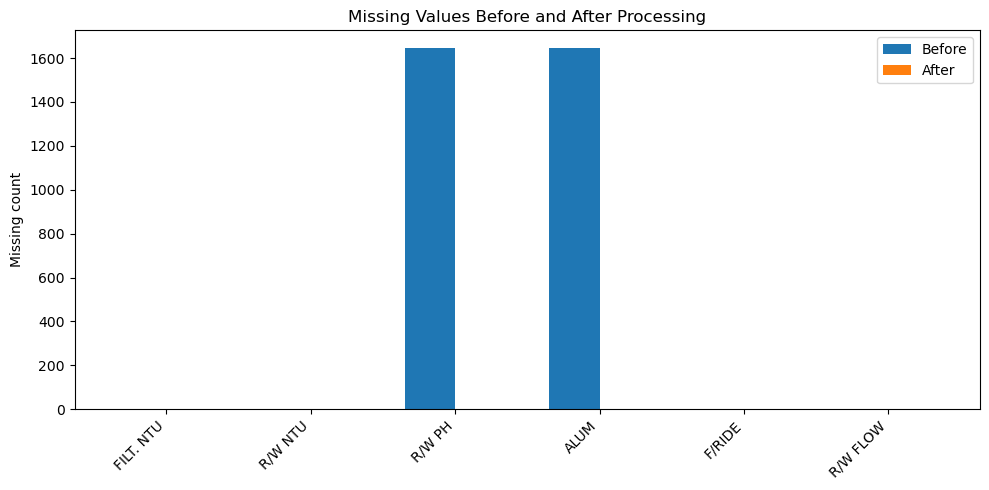

缺失值图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_missing_before_after.png


In [13]:
missing_plot_df = missing_audit.copy()

x = np.arange(len(missing_plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, missing_plot_df["missing_count_before"], width, label="Before")
plt.bar(x + width / 2, missing_plot_df["missing_count_after"], width, label="After")
plt.xticks(x, missing_plot_df["column"], rotation=45, ha="right")
plt.ylabel("Missing count")
plt.title("Missing Values Before and After Processing")
plt.legend()
plt.tight_layout()

missing_fig_path = FIG_DIR / "problem2_missing_before_after.png"
plt.savefig(missing_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("缺失值图已保存：", missing_fig_path)


## 14. 可视化 2：差分前后和截断分布

输出：

```text
figures/problem2_target_raw_diff_vs_clip1_distribution.png
```


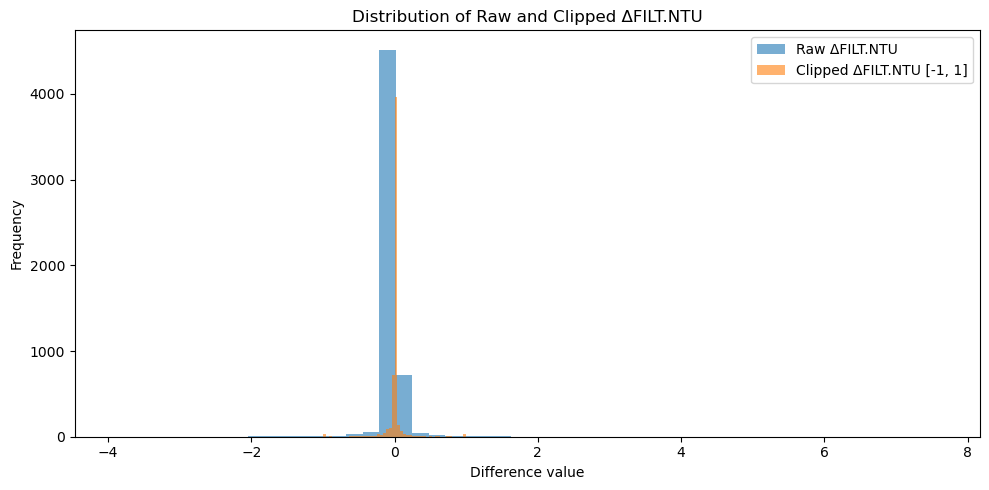

差分分布图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_target_raw_diff_vs_clip1_distribution.png


In [14]:
raw_target_diff = clip_data[target_diff_col].dropna()
clip_target_diff = clip_data[target_clip_col].dropna()

plt.figure(figsize=(10, 5))
plt.hist(raw_target_diff, bins=50, alpha=0.6, label="Raw ΔFILT.NTU")
plt.hist(clip_target_diff, bins=50, alpha=0.6, label="Clipped ΔFILT.NTU [-1, 1]")
plt.xlabel("Difference value")
plt.ylabel("Frequency")
plt.title("Distribution of Raw and Clipped ΔFILT.NTU")
plt.legend()
plt.tight_layout()

diff_dist_fig_path = FIG_DIR / "problem2_target_raw_diff_vs_clip1_distribution.png"
plt.savefig(diff_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("差分分布图已保存：", diff_dist_fig_path)


## 15. 可视化 3：模型性能对比

输出：

```text
figures/problem2_model_test_rmse_comparison.png
figures/problem2_model_test_r2_comparison.png
figures/problem2_model_direction_accuracy_comparison.png
```


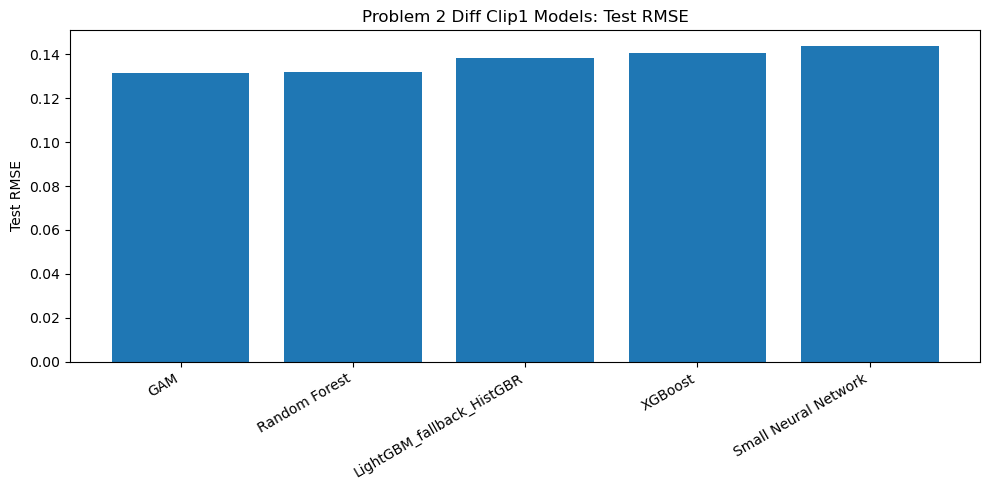

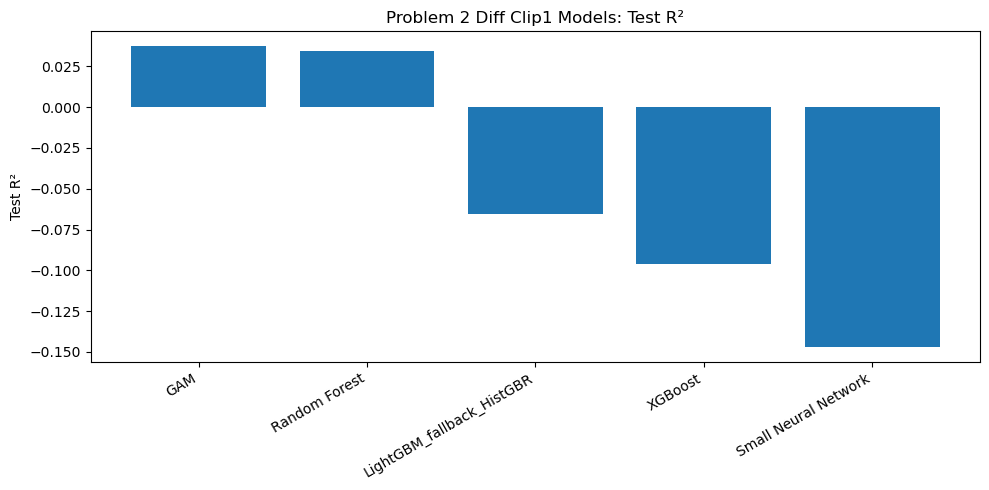

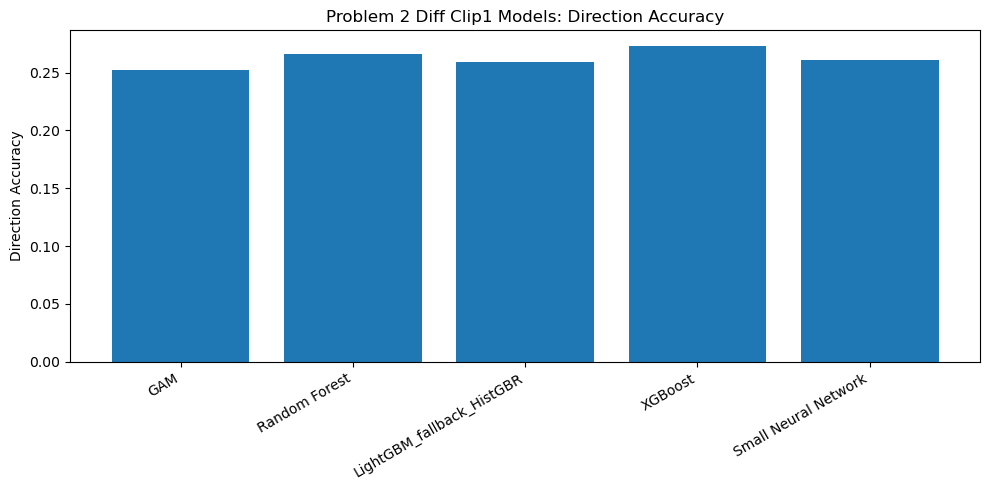

RMSE 图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_model_test_rmse_comparison.png
R² 图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_model_test_r2_comparison.png
方向准确率图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_model_direction_accuracy_comparison.png


In [15]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["test_RMSE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test RMSE")
plt.title("Problem 2 Diff Clip1 Models: Test RMSE")
plt.tight_layout()

rmse_fig_path = FIG_DIR / "problem2_model_test_rmse_comparison.png"
plt.savefig(rmse_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["test_R2"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test R²")
plt.title("Problem 2 Diff Clip1 Models: Test R²")
plt.tight_layout()

r2_fig_path = FIG_DIR / "problem2_model_test_r2_comparison.png"
plt.savefig(r2_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["test_Direction_Accuracy"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Direction Accuracy")
plt.title("Problem 2 Diff Clip1 Models: Direction Accuracy")
plt.tight_layout()

direction_fig_path = FIG_DIR / "problem2_model_direction_accuracy_comparison.png"
plt.savefig(direction_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("RMSE 图已保存：", rmse_fig_path)
print("R² 图已保存：", r2_fig_path)
print("方向准确率图已保存：", direction_fig_path)


## 16. 可视化 4：最佳模型实际值 vs 预测值

根据测试集 RMSE 最小选择最佳模型。


最佳模型： GAM


,model,n_features,train_samples,test_samples,train_MAE,train_RMSE,train_R2,train_Direction_Accuracy,test_MAE,test_RMSE,test_R2,test_Direction_Accuracy
0,GAM,38,4367,1092,0.044869,0.132608,0.135025,0.252347,0.044578,0.13173,0.037213,0.251832


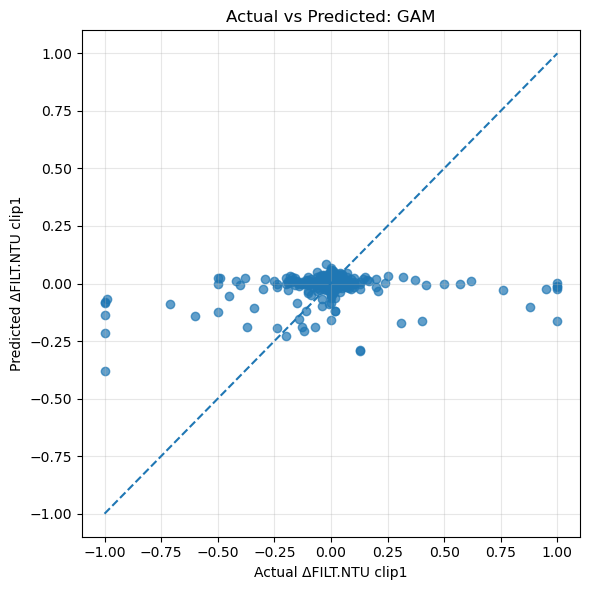

实际-预测散点图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_best_model_actual_vs_predicted.png


In [16]:
best_model_name = results_df.iloc[0]["model"]
best_pred_df = predictions_df[predictions_df["model"] == best_model_name].copy()

print("最佳模型：", best_model_name)
display(results_df.iloc[[0]])

plt.figure(figsize=(6, 6))
plt.scatter(
    best_pred_df[target_name],
    best_pred_df["predicted_DIFF_FILT_NTU_CLIP1"],
    alpha=0.7,
)
plt.plot([DIFF_CLIP_LOWER, DIFF_CLIP_UPPER], [DIFF_CLIP_LOWER, DIFF_CLIP_UPPER], linestyle="--")
plt.xlabel("Actual ΔFILT.NTU clip1")
plt.ylabel("Predicted ΔFILT.NTU clip1")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()

scatter_fig_path = FIG_DIR / "problem2_best_model_actual_vs_predicted.png"
plt.savefig(scatter_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("实际-预测散点图已保存：", scatter_fig_path)


## 17. 可视化 5：最佳模型测试集时间曲线

虽然数据划分是随机的，但为了观察波动模式，这里按 `DATETIME` 排序后画测试集实际/预测曲线。


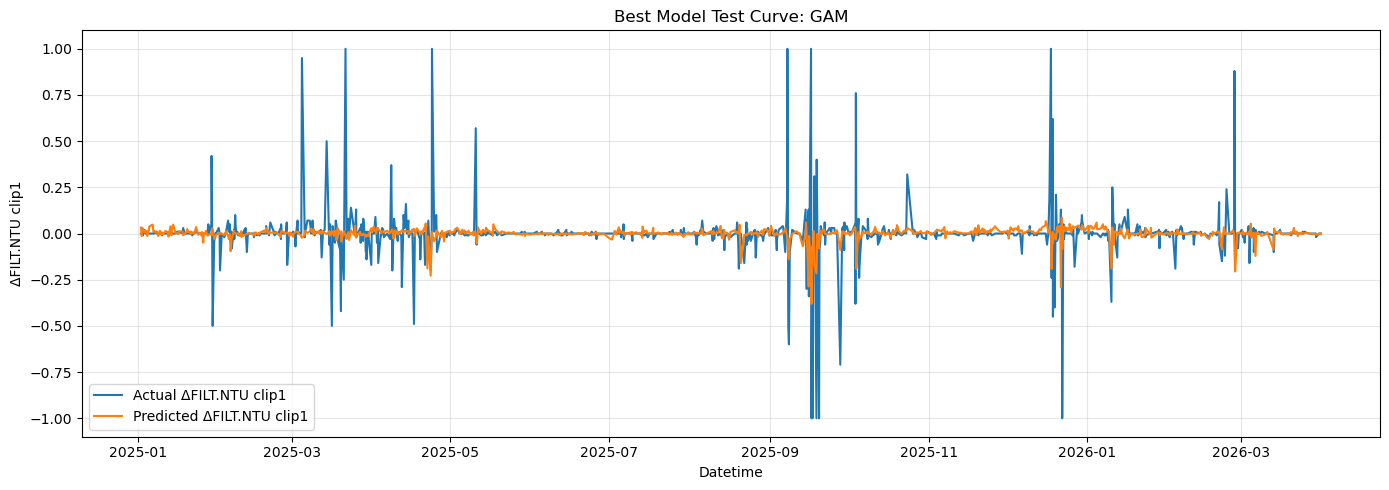

测试集时间曲线已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_best_model_test_timeseries.png


In [17]:
plt.figure(figsize=(14, 5))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df[target_name],
    label="Actual ΔFILT.NTU clip1",
    linewidth=1.5,
)
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["predicted_DIFF_FILT_NTU_CLIP1"],
    label="Predicted ΔFILT.NTU clip1",
    linewidth=1.5,
)
plt.xlabel("Datetime")
plt.ylabel("ΔFILT.NTU clip1")
plt.title(f"Best Model Test Curve: {best_model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ts_fig_path = FIG_DIR / "problem2_best_model_test_timeseries.png"
plt.savefig(ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("测试集时间曲线已保存：", ts_fig_path)


## 18. 可视化 6：最佳模型残差分布与残差曲线

输出：

```text
figures/problem2_best_model_residual_distribution.png
figures/problem2_best_model_residual_timeseries.png
```


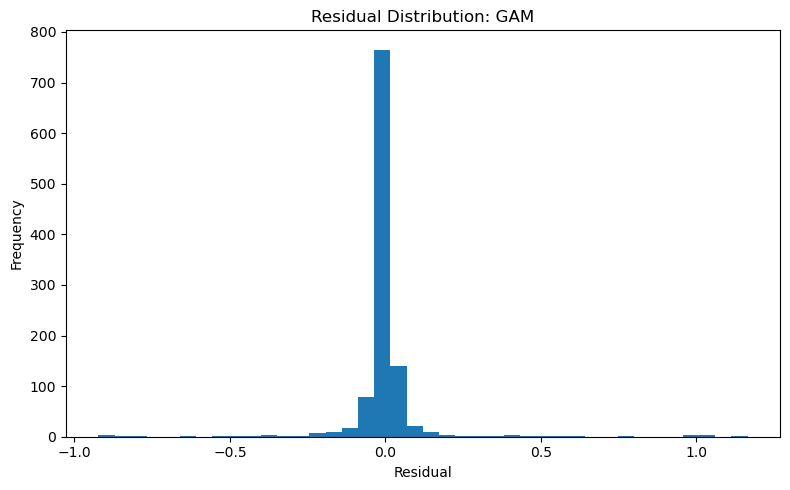

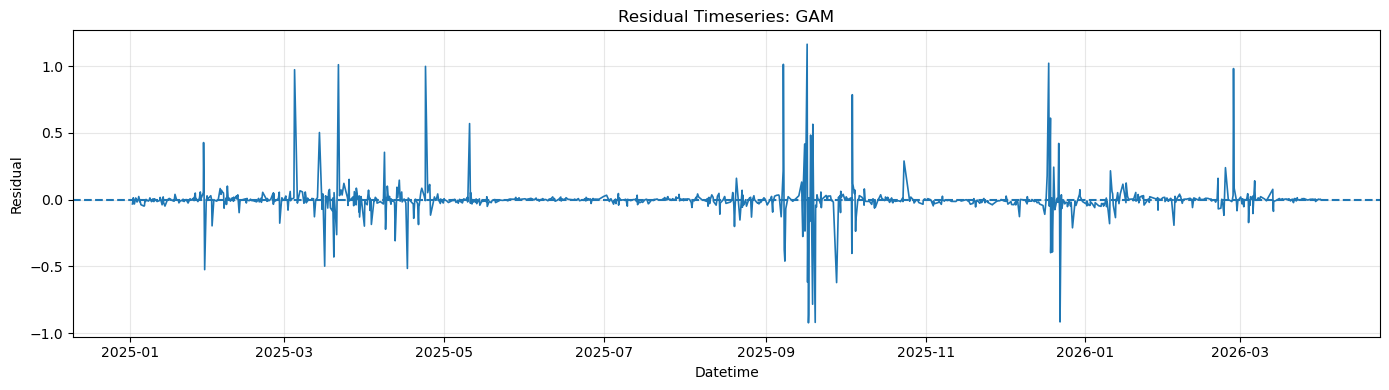

残差分布图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_best_model_residual_distribution.png
残差曲线图已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_best_model_residual_timeseries.png


In [18]:
plt.figure(figsize=(8, 5))
plt.hist(best_pred_df["residual"], bins=40)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(f"Residual Distribution: {best_model_name}")
plt.tight_layout()

resid_dist_fig_path = FIG_DIR / "problem2_best_model_residual_distribution.png"
plt.savefig(resid_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["residual"],
    linewidth=1.2,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.title(f"Residual Timeseries: {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()

resid_ts_fig_path = FIG_DIR / "problem2_best_model_residual_timeseries.png"
plt.savefig(resid_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("残差分布图已保存：", resid_dist_fig_path)
print("残差曲线图已保存：", resid_ts_fig_path)


## 19. 可视化 7：特征重要性

如果有树模型特征重要性，则绘制每个模型 Top 15 特征。


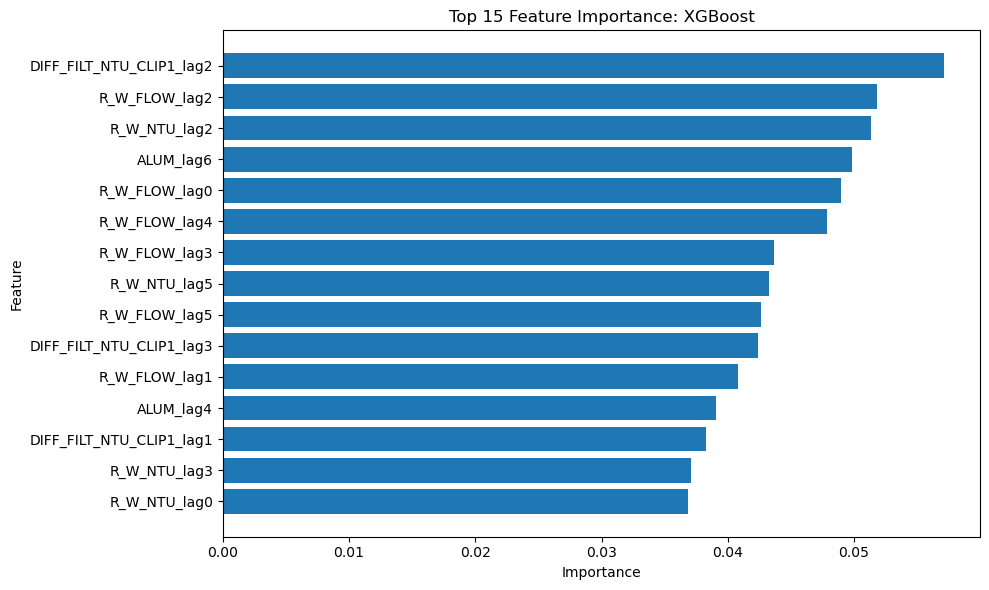

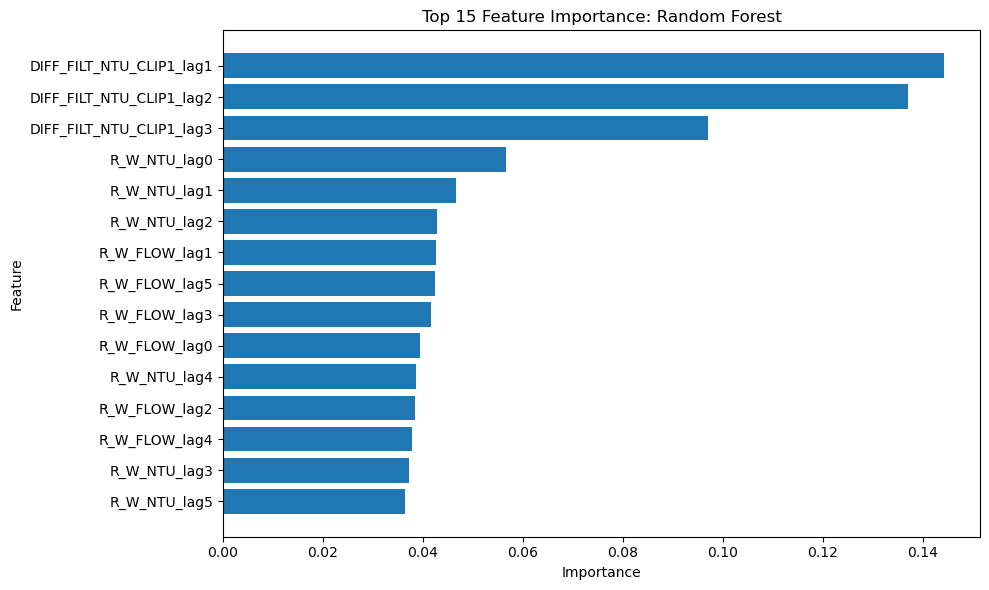

特征重要性图：
/Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_feature_importance_XGBoost.png
/Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/figures/problem2_feature_importance_Random_Forest.png


In [19]:
importance_fig_paths = []

if len(importance_df) > 0:
    for model_name in importance_df["model"].unique():
        temp = importance_df[importance_df["model"] == model_name].sort_values("importance", ascending=False).head(15)

        plt.figure(figsize=(10, 6))
        plt.barh(temp["feature"][::-1], temp["importance"][::-1])
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.title(f"Top 15 Feature Importance: {model_name}")
        plt.tight_layout()

        fig_path = FIG_DIR / f"problem2_feature_importance_{model_name}.png".replace(" ", "_").replace("/", "_")
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()

        importance_fig_paths.append(fig_path)

    print("特征重要性图：")
    for p in importance_fig_paths:
        print(p)
else:
    print("没有可用的 feature_importances_，跳过特征重要性可视化。")


## 20. 输出汇总工作簿和最终摘要

输出：

```text
problem2_diff_clip1_summary.xlsx
problem2_diff_clip1_final_summary.xlsx
```


In [20]:
summary_workbook_path = OUTPUT_DIR / "problem2_diff_clip1_summary.xlsx"

with pd.ExcelWriter(summary_workbook_path, engine="openpyxl") as writer:
    missing_audit.to_excel(writer, sheet_name="missing_audit", index=False)
    clip_audit_df.to_excel(writer, sheet_name="clip_audit", index=False)
    feature_summary_df.to_excel(writer, sheet_name="feature_summary", index=False)
    results_df.to_excel(writer, sheet_name="model_results", index=False)
    predictions_df.to_excel(writer, sheet_name="test_predictions", index=False)
    importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

final_summary = pd.DataFrame([
    {
        "item": "model_family",
        "value": "First-difference clipped model for P2 FILT. NTU",
    },
    {
        "item": "target",
        "value": "ΔFILT.NTU clipped to [-1, 1]",
    },
    {
        "item": "difference_rule",
        "value": "only FILT. NTU is differenced as current value minus previous time node value; predictors retain their original levels",
    },
    {
        "item": "clipping_rule",
        "value": "positive values are capped at 1 and negative values are capped at -1",
    },
    {
        "item": "missing_value_handling",
        "value": "F/RIDE filled with 0; R/W PH filled with 7; ALUM filled with 0.06; other variables linearly interpolated, then ffill/bfill; model features additionally handled by median imputer in pipeline.",
    },
    {
        "item": "data_split",
        "value": "random 80% train / 20% test",
    },
    {
        "item": "models",
        "value": ", ".join(results_df["model"].tolist()),
    },
    {
        "item": "best_model",
        "value": best_model_name,
    },
    {
        "item": "best_test_MAE",
        "value": results_df.iloc[0]["test_MAE"],
    },
    {
        "item": "best_test_RMSE",
        "value": results_df.iloc[0]["test_RMSE"],
    },
    {
        "item": "best_test_R2",
        "value": results_df.iloc[0]["test_R2"],
    },
    {
        "item": "best_test_direction_accuracy",
        "value": results_df.iloc[0]["test_Direction_Accuracy"],
    },
])

final_summary_path = OUTPUT_DIR / "problem2_diff_clip1_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)

print("汇总工作簿已保存：", summary_workbook_path)
print("最终摘要已保存：", final_summary_path)

display(final_summary)


汇总工作簿已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_summary.xlsx
最终摘要已保存： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_final_summary.xlsx


,item,value
0,model_family,First-difference clipped model for P2 FILT. NTU
1,target,"ΔFILT.NTU clipped to [-1, 1]"
2,difference_rule,only FILT. NTU is differenced as current value...
3,clipping_rule,positive values are capped at 1 and negative v...
4,missing_value_handling,F/RIDE filled with 0; R/W PH filled with 7; AL...
5,data_split,random 80% train / 20% test
6,models,"GAM, Random Forest, LightGBM_fallback_HistGBR,..."
7,best_model,GAM
8,best_test_MAE,0.044578
9,best_test_RMSE,0.13173


## 21. 论文中可以使用的说明

```text
为突出滤后水浊度变化趋势而非绝对值，本文对 FILT. NTU 及第二问核心输入变量进行一阶差分处理，即以当前时刻值减去前一时间节点值。随后对差分值进行截断，将大于 1 的正向变化截断为 1，将小于 -1 的负向变化截断为 -1，以降低异常突变对模型训练的影响。缺失值方面，F/RIDE 缺失填充为 0，其余数值变量采用时间顺序线性插值并结合前后向填充。处理后的样本随机划分为 80% 训练集和 20% 测试集，并使用 XGBoost、GAM、Random Forest、LightGBM 和小型神经网络进行拟合比较。
```


In [21]:
print("=" * 80)
print("问题二目标差分 + 原始自变量 + 随机 80/20 + 五模型拟合流程已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. 缺失值审计：", missing_audit_path)
print("2. 原始差分数据：", diff_raw_path)
print("3. 差分截断审计：", clip_audit_path)
print("4. 差分截断数据：", clip_data_path)
print("5. 建模数据：", model_data_path)
print("6. 特征说明：", feature_summary_path)
print("7. 模型结果：", results_path)
print("8. 测试集预测：", predictions_path)
print("9. 特征重要性：", importance_path)
print("10. 汇总工作簿：", summary_workbook_path)
print("11. 最终摘要：", final_summary_path)
print("12. 图片目录：", FIG_DIR)
print("13. 模型目录：", MODEL_DIR)

print("\n模型结果：")
display(results_df)

print("\n最佳模型：")
display(results_df.iloc[[0]])

print("\n最终摘要：")
display(final_summary)


问题二目标差分 + 原始自变量 + 随机 80/20 + 五模型拟合流程已完成。

核心输出文件：
1. 缺失值审计： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_missing_audit.xlsx
2. 原始差分数据： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_raw_data.xlsx
3. 差分截断审计： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_audit.xlsx
4. 差分截断数据： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_data.xlsx
5. 建模数据： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_model_data.xlsx
6. 特征说明： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_feature_summary.xlsx
7. 模型结果： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_model_results.xlsx
8. 测试集预测： /Users/jinyu/workspace/2026亚太杯/outputs/problem2_diff_clip1_random80/problem2_diff_clip1_test_predictions.xlsx
9. 特征重要性： /Users/jinyu/workspace/2026亚太杯

,model,n_features,train_samples,test_samples,train_MAE,train_RMSE,train_R2,train_Direction_Accuracy,test_MAE,test_RMSE,test_R2,test_Direction_Accuracy
0,GAM,38,4367,1092,0.044869,0.132608,0.135025,0.252347,0.044578,0.131730,0.037213,0.251832
1,Random Forest,38,4367,1092,0.024098,0.078380,0.697812,0.414472,0.042441,0.131945,0.034065,0.266484
2,LightGBM_fallback_HistGBR,38,4367,1092,0.024468,0.058198,0.833400,0.318525,0.049699,0.138564,-0.065284,0.259158
3,XGBoost,38,4367,1092,0.030187,0.081842,0.670531,0.284177,0.045101,0.140557,-0.096148,0.272894
4,Small Neural Network,38,4367,1092,0.058161,0.131783,0.145750,0.241356,0.063510,0.143764,-0.146731,0.260989



最佳模型：


,model,n_features,train_samples,test_samples,train_MAE,train_RMSE,train_R2,train_Direction_Accuracy,test_MAE,test_RMSE,test_R2,test_Direction_Accuracy
0,GAM,38,4367,1092,0.044869,0.132608,0.135025,0.252347,0.044578,0.13173,0.037213,0.251832



最终摘要：


,item,value
0,model_family,First-difference clipped model for P2 FILT. NTU
1,target,"ΔFILT.NTU clipped to [-1, 1]"
2,difference_rule,only FILT. NTU is differenced as current value...
3,clipping_rule,positive values are capped at 1 and negative v...
4,missing_value_handling,F/RIDE filled with 0; R/W PH filled with 7; AL...
5,data_split,random 80% train / 20% test
6,models,"GAM, Random Forest, LightGBM_fallback_HistGBR,..."
7,best_model,GAM
8,best_test_MAE,0.044578
9,best_test_RMSE,0.13173
